In [ ]:
import sys
import os
import torch
from model.msmrec import *
from utils import *
from tqdm import tqdm
import os
import pickle
import argparse

In [6]:
num_u, num_i = get_usr_itm_num('ml-1m')
train,valid,test = load_train_valid_test_data_num(ds_dict=load_txt_file('ml-1m'), itemnum=num_i)

FileNotFoundError: [Errno 2] No such file or directory: 'data/ml-1m/interaction.txt'

In [ ]:
num_u, num_i = get_usr_itm_num('ml-1m')
model = MSMRec(
    user_num=num_u,
    item_num=num_i,
    maxlen=200,
    num_blocks=2,
    num_heads=1,
    hidden_units=50,
    dropout_rate=0.2,
    num_modality=9,
    meta_emb=torch.zeros((num_i + 1,13824))
)

In [ ]:
model.load_state_dict(torch.load('checkpoints/ml-1m-MSMRec-best.pth', map_location='cuda'))

<All keys matched successfully>

##### We randomly select 20 users from popular and 20 users from niche groups to check logits distribution

In [ ]:
import json
popularity = json.load(open('meta\ml-1m\popularity.json'))

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\kangr\AppData\Local\Temp\ipykernel_16744\497015063.py:2: SyntaxWarning: invalid escape sequence '\m'
  popularity = json.load(open('meta\ml-1m\popularity.json'))


In [ ]:
popular_usrs = list({int(k) for k , v in popularity.items() if v == 'split_1'})
niche_usrs = list({int(k) for k , v in popularity.items() if v == 'split_10'})

In [ ]:
import random
random.seed(42)
ex_pop_users = random.sample(popular_usrs, 20)
ex_nic_users = random.sample(niche_usrs, 20)

In [ ]:
seq_pop_users = [
    i[1] for i in train if i[0] in ex_pop_users
]
seq_nic_users = [
    i[1] for i in train if i[0] in ex_nic_users
]

In [ ]:
model = model.to('cuda')
pop_logits = model.get_user_logits(torch.LongTensor(seq_pop_users).to('cpu')).cpu().detach()
nic_logits = model.get_user_logits(torch.LongTensor(seq_nic_users).to('cpu')).cpu().detach()

d:\CDS\DSGA1012-Natural Langauge Understanding\NLU-Final-Project\model\msmrec.py:73: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  seqs +=self.pos_emb(torch.tensor(poss, dtype=torch.long, device=self.dev))


In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Modality2Id = {
    'Narrative': 0, 'Dialogue': 1, 'Visual': 2, 'Set': 3, 'Audio': 4,
    'Pace': 5, 'Direction': 6, 'Acting': 7, 'Poster': 8
}
modality_names = list(Modality2Id.keys())

def plot_in_group_distribution_seaborn(pop_logits, nic_logits, modality_names):
    def logits_to_df(logits_tensor, group_label):
        df = pd.DataFrame(logits_tensor.numpy(), columns=modality_names)
        df['user_id'] = df.index
        df = df.melt(id_vars='user_id', var_name='modality', value_name='logit')
        df['group'] = group_label
        df['modality'] = pd.Categorical(df['modality'], categories=modality_names, ordered=True)
        return df

    pop_df = logits_to_df(pop_logits, 'Popular')
    nic_df = logits_to_df(nic_logits, 'Niche')
    full_df = pd.concat([pop_df, nic_df])

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=full_df, x='modality', y='logit', hue='group', units='user_id',
                 estimator=None, alpha=0.2, lw=1)
    plt.title('User-wise Logit Distribution by Modality')
    plt.ylabel('Logit Value')
    plt.xlabel('Modality')
    plt.tight_layout()
    plt.show()

def plot_between_group_distribution_seaborn(pop_logits, nic_logits, modality_names):
    def logits_summary_df(logits_tensor, group_label):
        df = pd.DataFrame(logits_tensor.numpy(), columns=modality_names)
        df['group'] = group_label
        df = df.melt(id_vars='group', var_name='modality', value_name='logit')
        df['modality'] = pd.Categorical(df['modality'], categories=modality_names, ordered=True)
        return df

    pop_df = logits_summary_df(pop_logits, 'Popular')
    nic_df = logits_summary_df(nic_logits, 'Niche')
    combined_df = pd.concat([pop_df, nic_df])
    mean_df = combined_df.groupby(['group', 'modality'], as_index=False)['logit'].mean()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=mean_df, x='modality', y='logit', hue='group')
    plt.title('Mean Logit per Modality (Popular vs Niche Users)')
    plt.ylabel('Mean Logit')
    plt.xlabel('Modality')
    plt.tight_layout()
    plt.show()


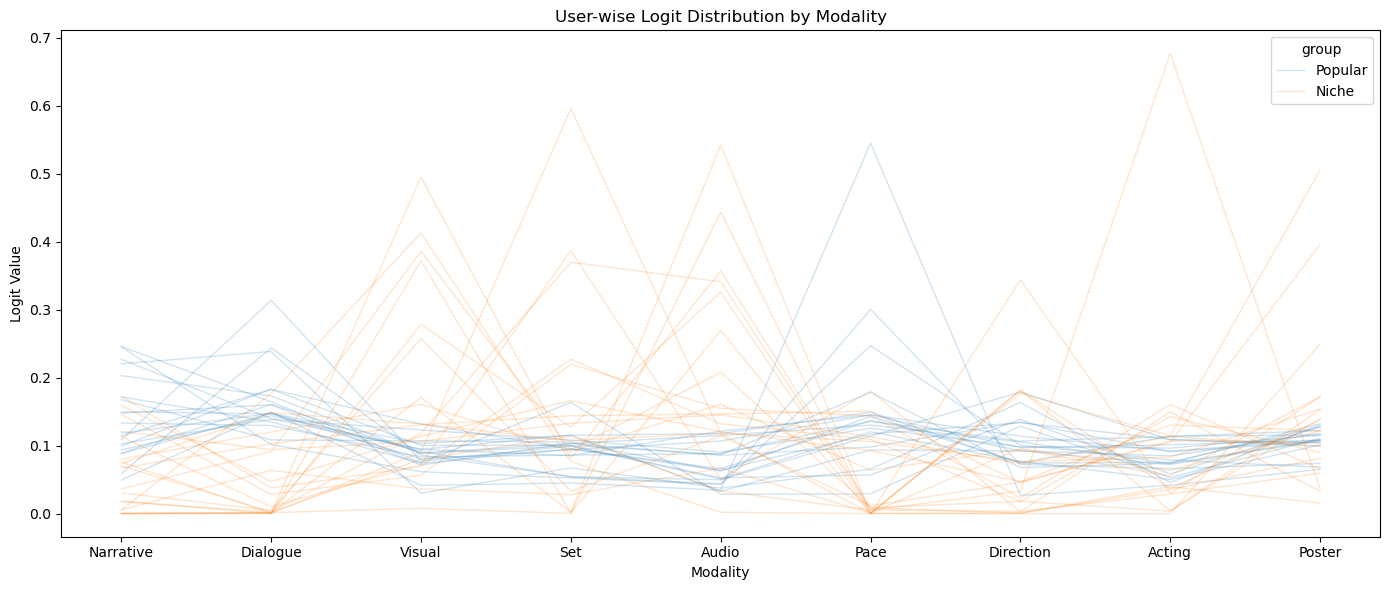

C:\Users\kangr\AppData\Local\Temp\ipykernel_16744\578326424.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = combined_df.groupby(['group', 'modality'], as_index=False)['logit'].mean()


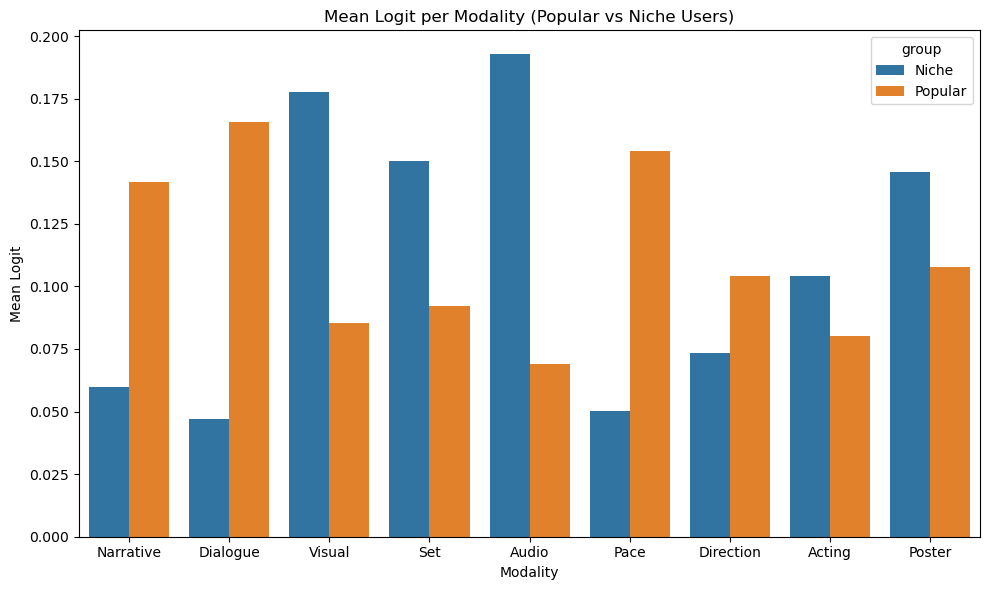

In [ ]:
plot_in_group_distribution_seaborn(pop_logits, nic_logits, modality_names)
plot_between_group_distribution_seaborn(pop_logits, nic_logits, modality_names)
